In [ ]:
!nvidia-smi

Sat May  9 20:46:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Cell 1: Clone repo and install dependencies
!git clone https://github.com/Vioxacute/satellite-vehicle-detector.git
%cd satellite-vehicle-detector
!pip install -q ultralytics roboflow pyyaml

Cloning into 'satellite-vehicle-detector'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 12 (delta 0), reused 12 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 1.81 MiB | 22.37 MiB/s, done.
/content/satellite-vehicle-detector
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 127.3 MB/s eta 0:00:00


In [ ]:
# Cell 2: Download dataset using your Roboflow API key
import os
from pathlib import Path
from google.colab import userdata
from roboflow import Roboflow

os.makedirs("data", exist_ok=True)
os.chdir("data")

api_key = userdata.get("ROBOFLOW_API_KEY")
rf = Roboflow(api_key=api_key)
project = rf.workspace("militaryvehiclerecognition").project("military-vehicle-recognition")
version = project.version(7)
dataset = version.download("yolov8")

os.chdir("..")
print(f"\nDataset downloaded to: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Military-Vehicle-Recognition-7 in yolov8:: 100%|██████████| 5738/5738 [00:00<00:00, 6540.29it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

Dataset downloaded to: /content/satellite-vehicle-detector/data/Military-Vehicle-Recognition-7


In [ ]:
# Cell 3: Rewrite data.yaml with absolute paths
import yaml
from pathlib import Path

dataset_folders = [f for f in Path("data").iterdir() if f.is_dir()]
DATASET_DIR = dataset_folders[0].absolute()
yaml_path = DATASET_DIR / "data.yaml"

with open(yaml_path) as f:
    config = yaml.safe_load(f)

config["train"] = str(DATASET_DIR / "train" / "images")
config["val"] = str(DATASET_DIR / "valid" / "images")
config["test"] = str(DATASET_DIR / "test" / "images")

with open(yaml_path, "w") as f:
    yaml.safe_dump(config, f, sort_keys=False)

print(f"Dataset: {DATASET_DIR}")
print(f"\nUpdated data.yaml:\n")
print(open(yaml_path).read())

Dataset: /content/satellite-vehicle-detector/data/Military-Vehicle-Recognition-7

Updated data.yaml:

names:
- air-fighter
- armoured personnel carrier
- bomber
- soldier
- tank
nc: 5
roboflow:
  license: CC BY 4.0
  project: military-vehicle-recognition
  url: https://universe.roboflow.com/militaryvehiclerecognition/military-vehicle-recognition/dataset/7
  version: 7
  workspace: militaryvehiclerecognition
test: /content/satellite-vehicle-detector/data/Military-Vehicle-Recognition-7/test/images
train: /content/satellite-vehicle-detector/data/Military-Vehicle-Recognition-7/train/images
val: /content/satellite-vehicle-detector/data/Military-Vehicle-Recognition-7/valid/images



In [ ]:
# Cell 4: Train the model
from pathlib import Path
from ultralytics import YOLO

dataset_folders = [f for f in Path("data").iterdir() if f.is_dir()]
DATASET_DIR = dataset_folders[0]
DATA_YAML = DATASET_DIR / "data.yaml"

model = YOLO("yolov8n.pt")  # nano = smallest/fastest

results = model.train(
    data=str(DATA_YAML),
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project="models",
    name="vehicle_detector_v1",
    patience=15,
    save=True,
    plots=True,
)

print("\n✓ Training complete!")

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/Military-Vehicle-Recognition-7/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=vehicle_detector_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overl

In [ ]:
# Diagnostic: find where training results actually went
import subprocess
result = subprocess.run(["find", ".", "-name", "results.png", "-not", "-path", "*/.*"],
                        capture_output=True, text=True)
print("results.png locations:")
print(result.stdout if result.stdout else "  (none found — training didn't produce output)")

result = subprocess.run(["find", ".", "-name", "best.pt", "-not", "-path", "*/.*"],
                        capture_output=True, text=True)
print("\nbest.pt locations:")
print(result.stdout if result.stdout else "  (none found — training didn't produce a model)")

results.png locations:
./runs/detect/models/vehicle_detector_v1/results.png


best.pt locations:
./runs/detect/models/vehicle_detector_v1/weights/best.pt



=== Training curves ===


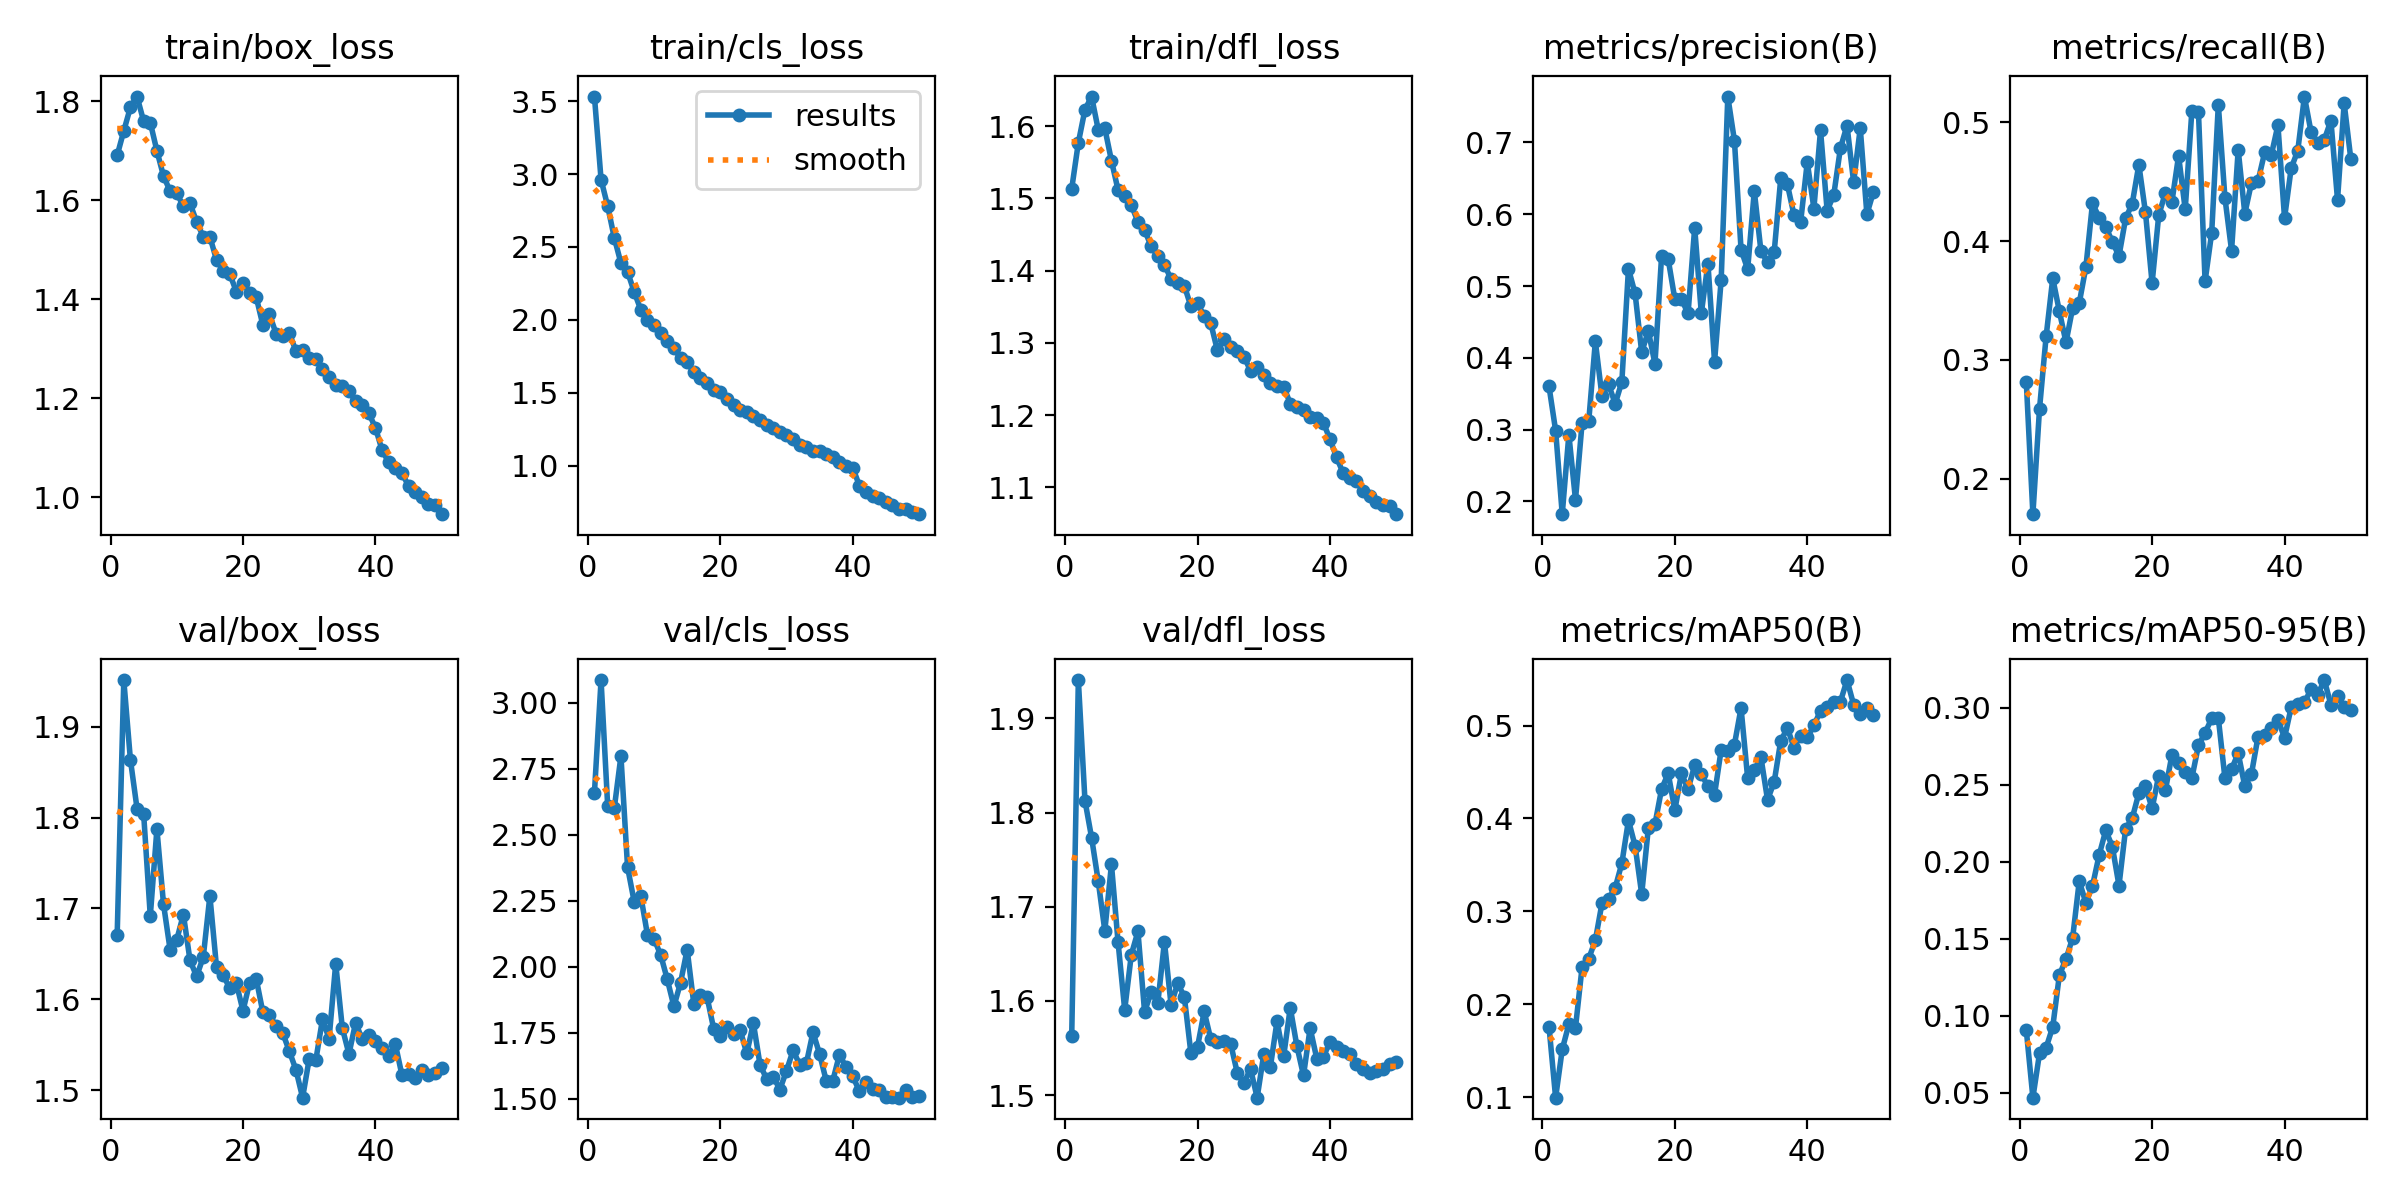


=== Confusion matrix ===


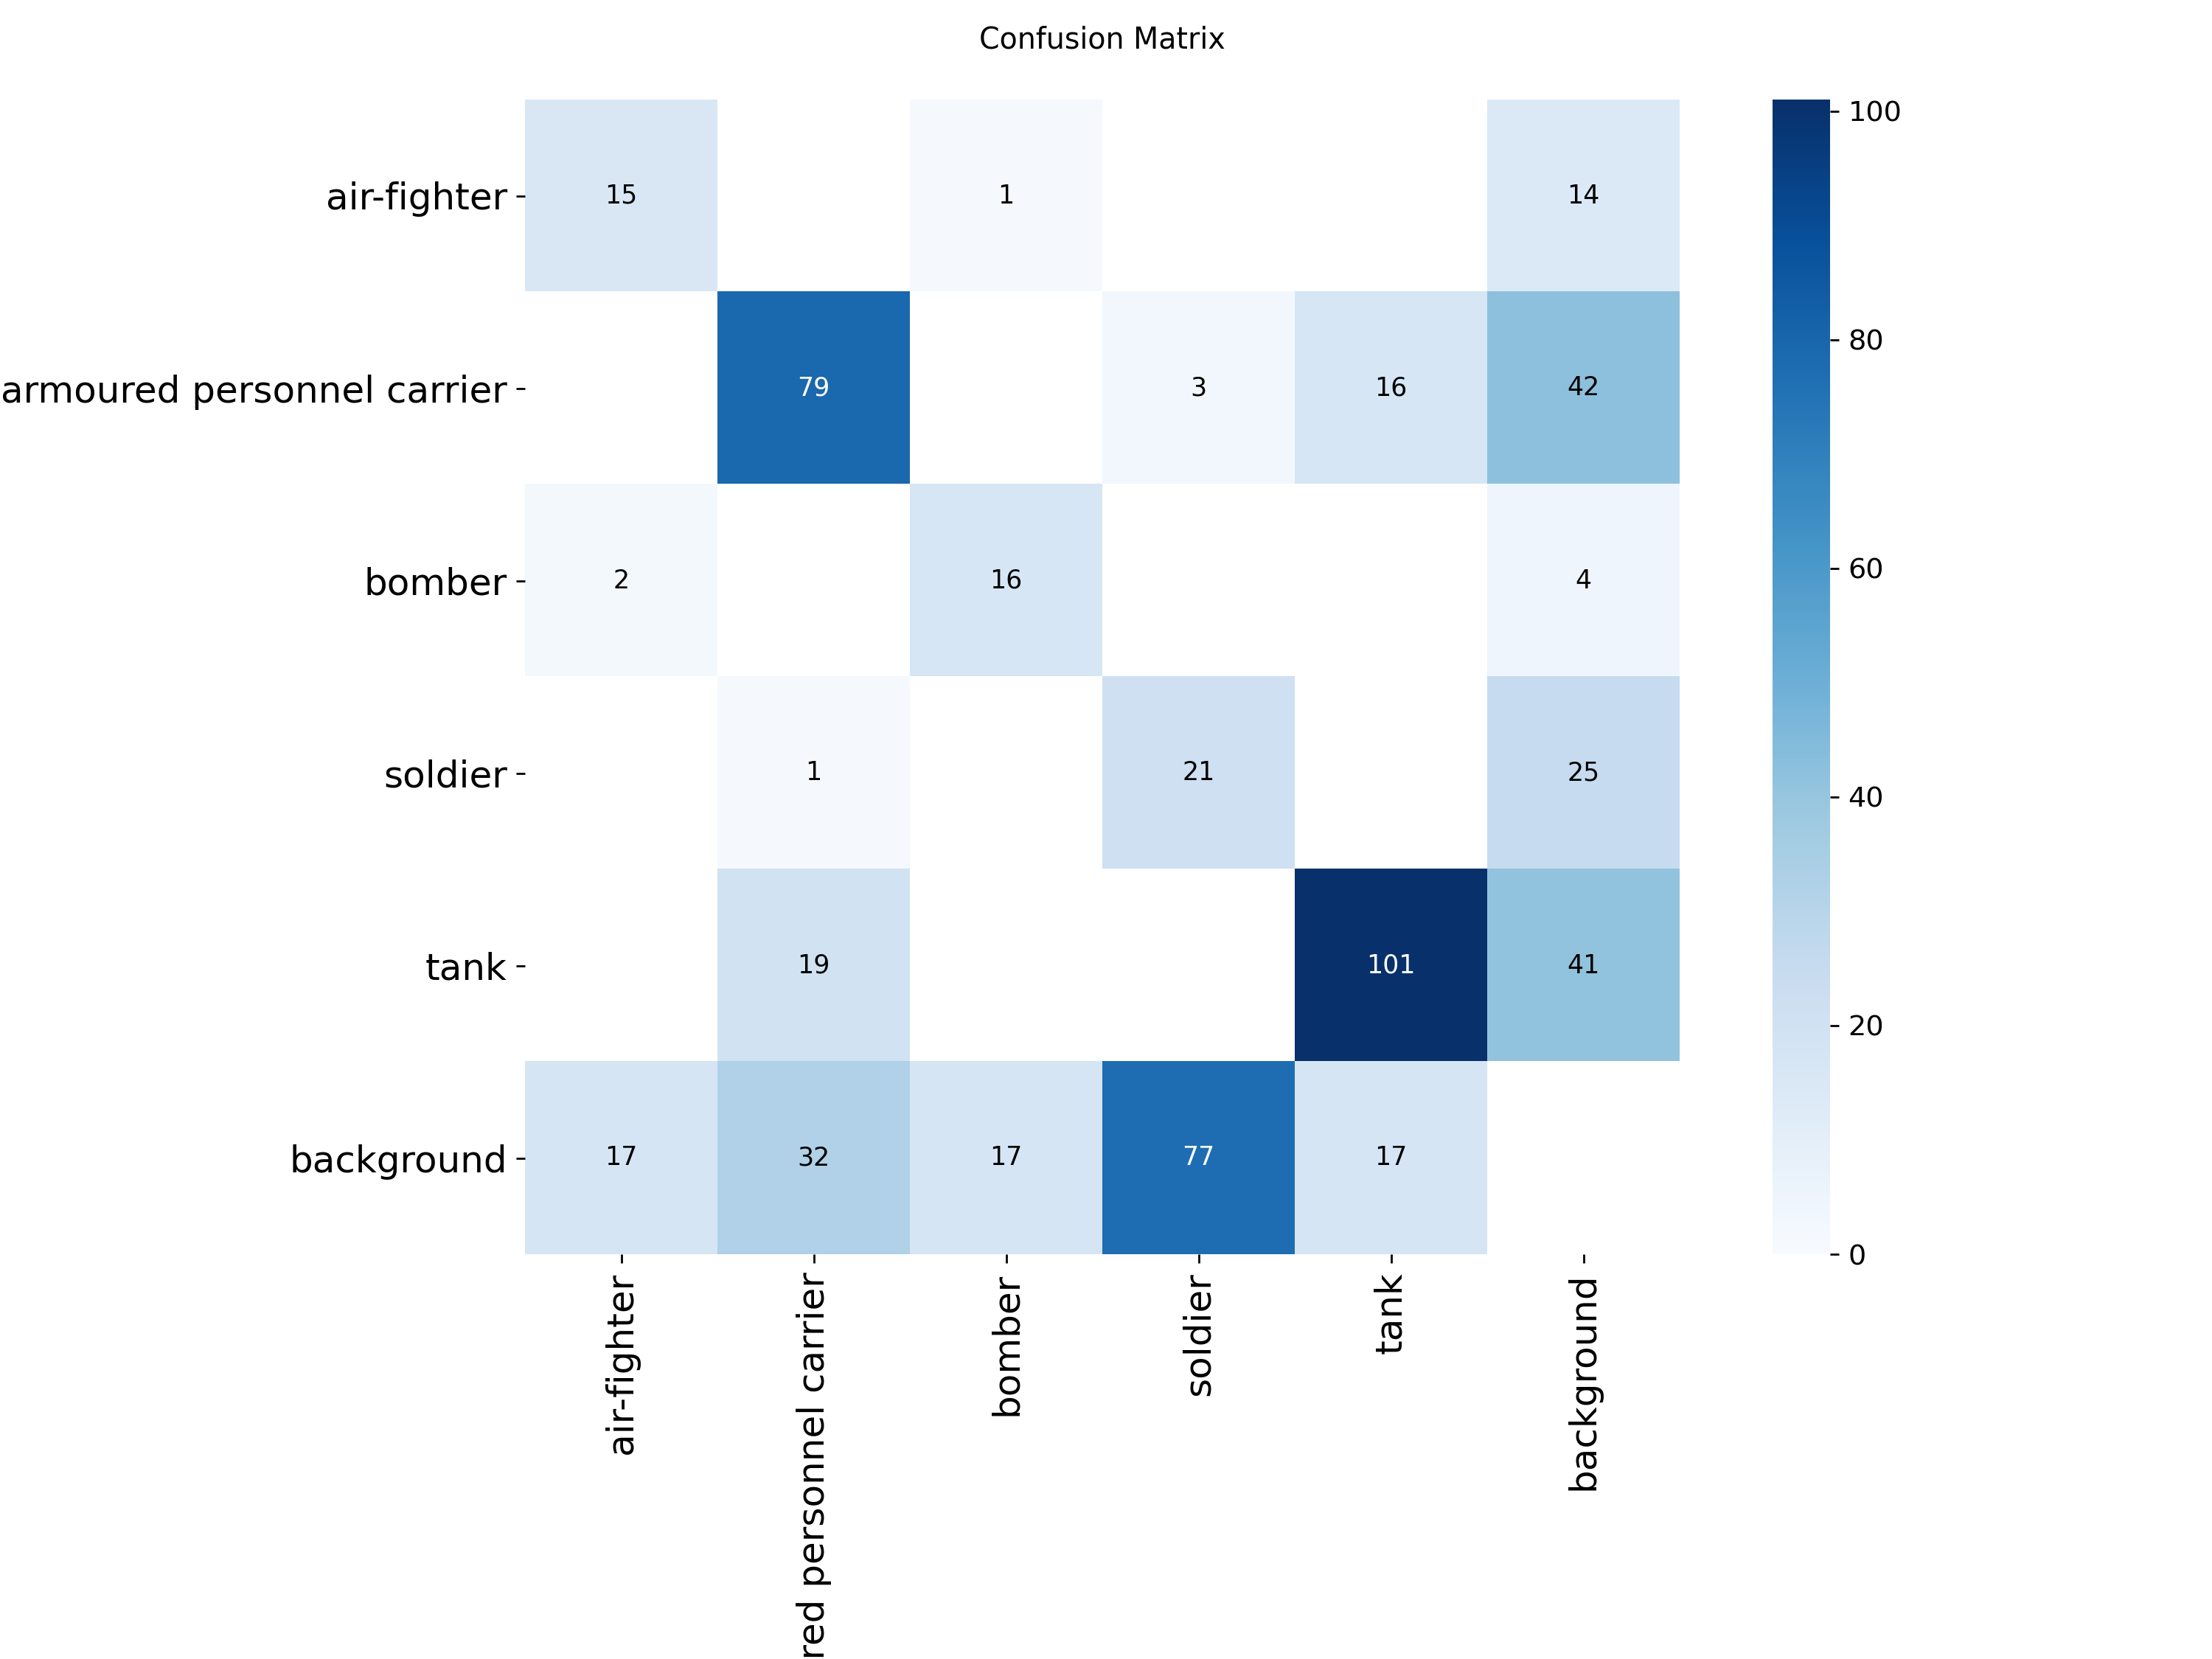


=== Sample predictions on validation set ===


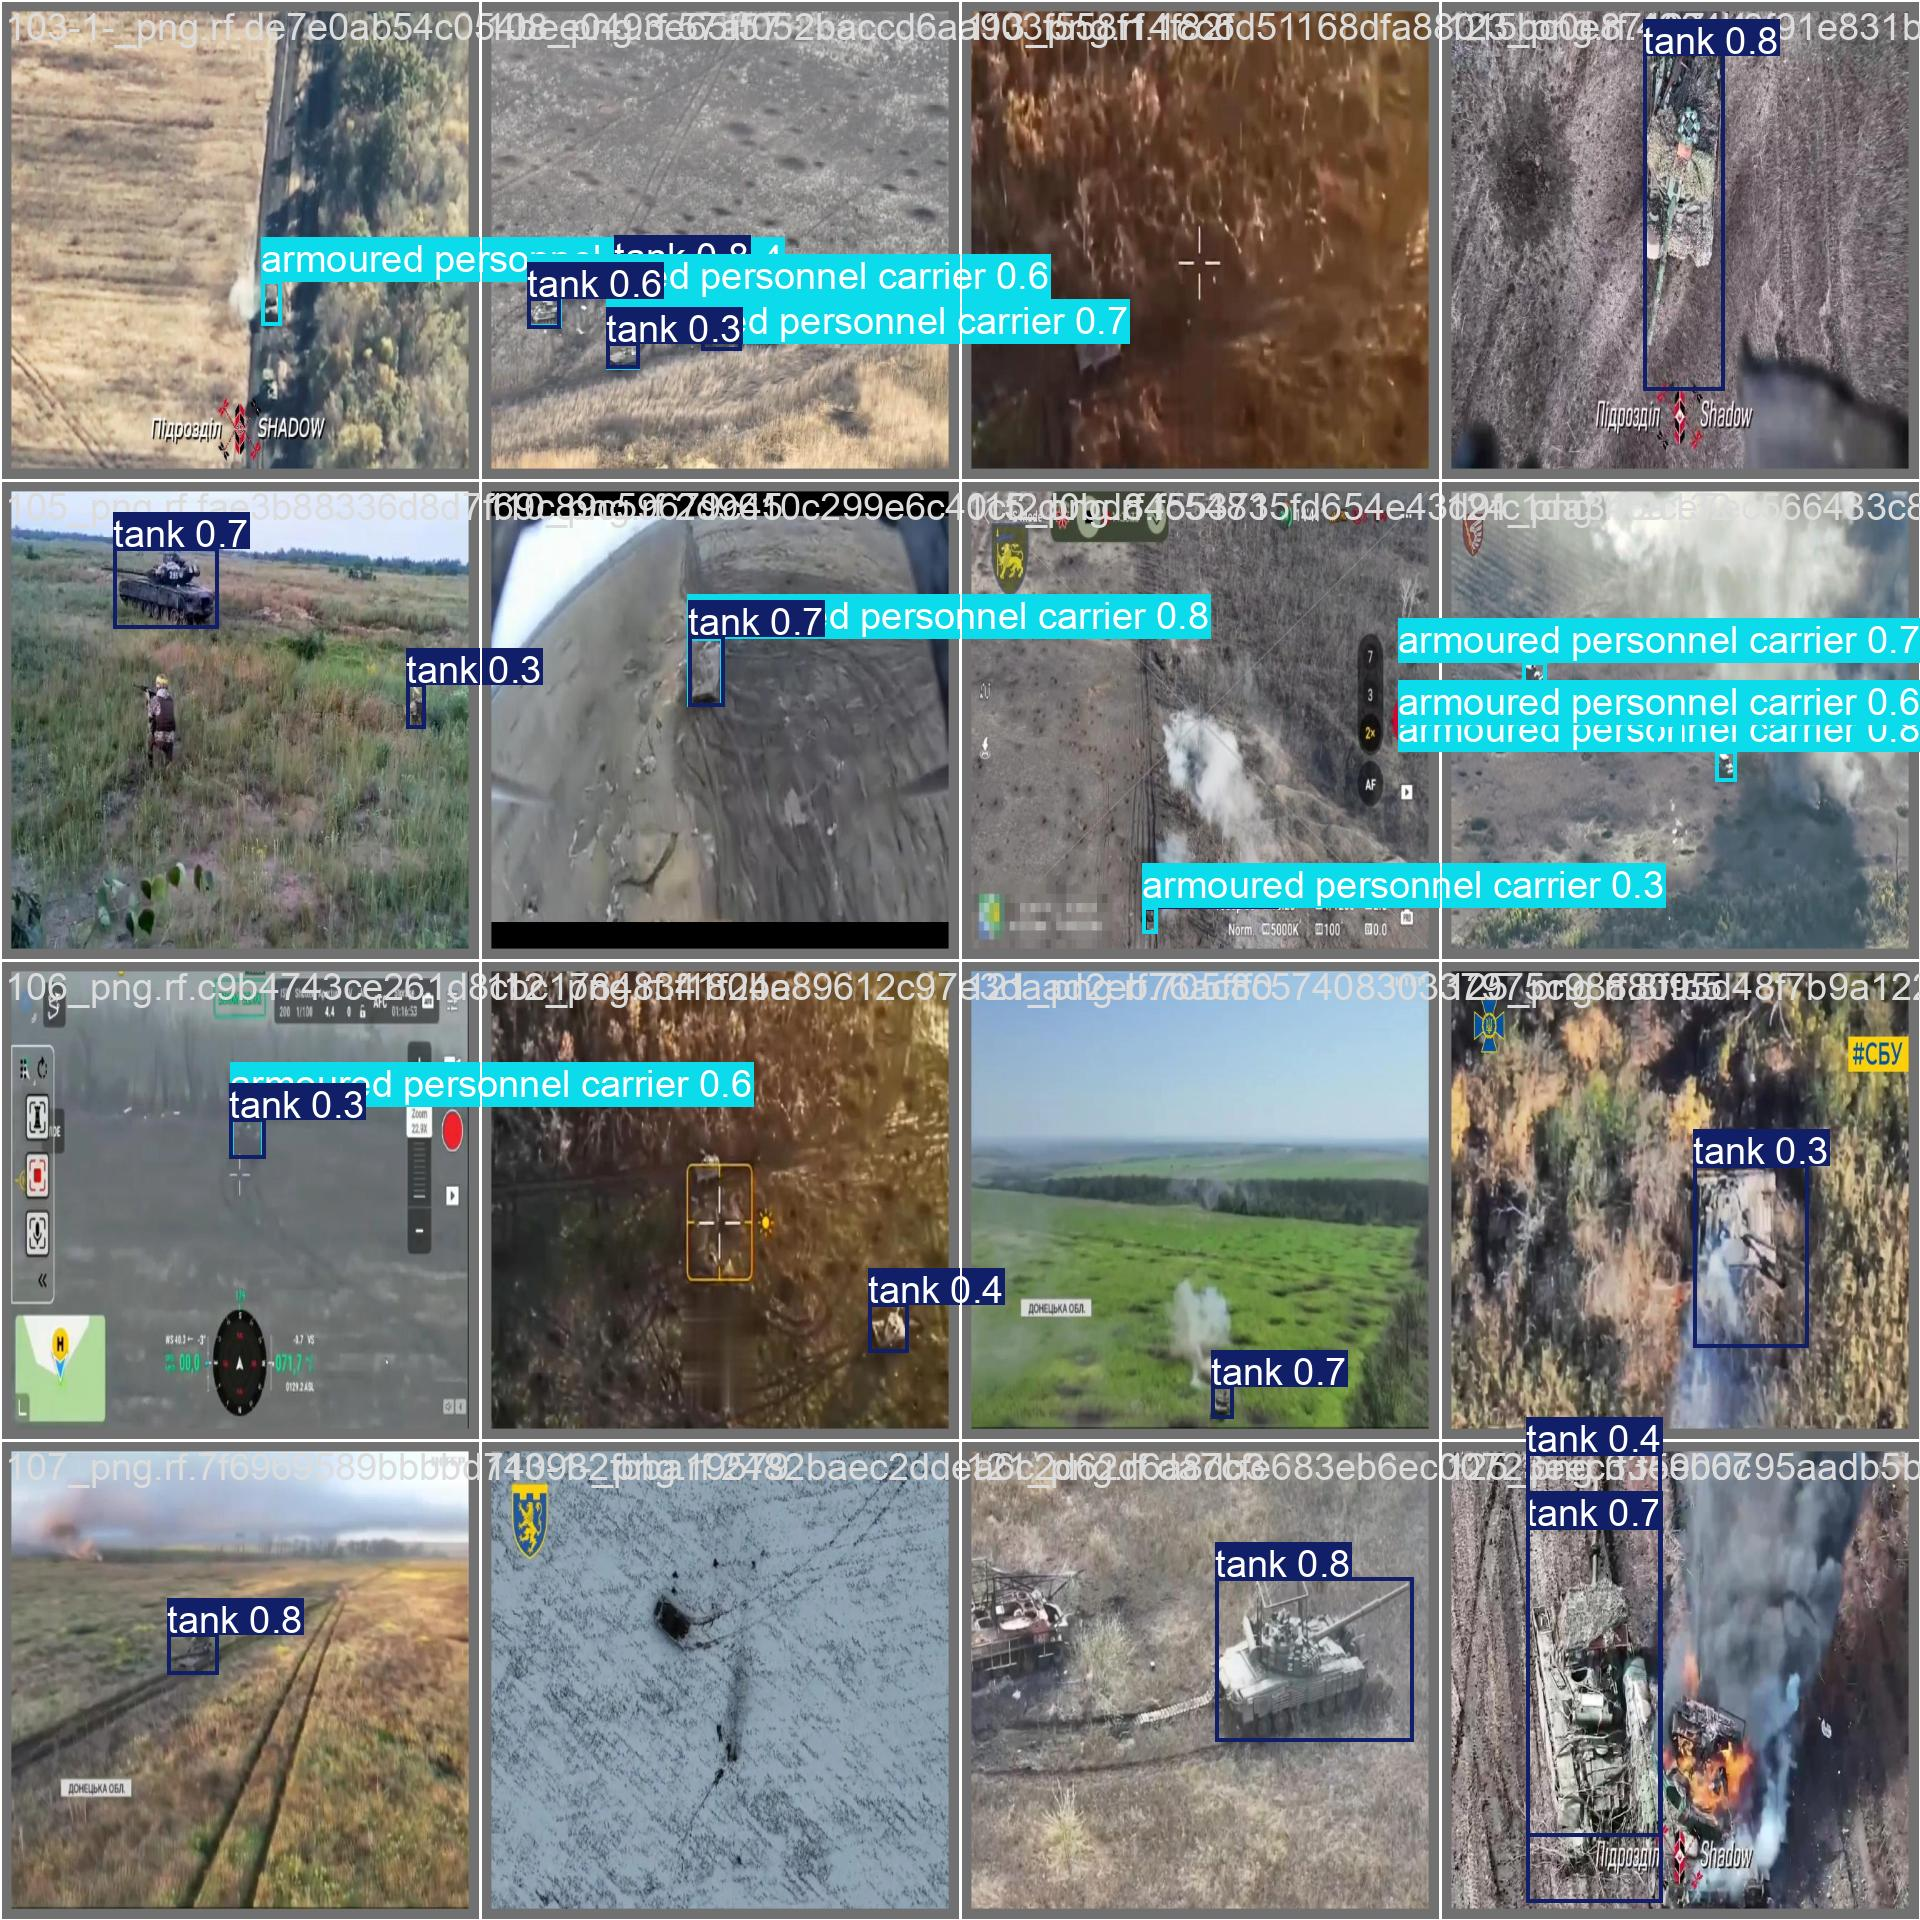

In [ ]:
# Cell 5: Display training artefacts
from IPython.display import Image, display
from pathlib import Path

results_dir = Path("runs/detect/models/vehicle_detector_v1")

print("=== Training curves ===")
display(Image(str(results_dir / "results.png")))

print("\n=== Confusion matrix ===")
display(Image(str(results_dir / "confusion_matrix.png")))

print("\n=== Sample predictions on validation set ===")
display(Image(str(results_dir / "val_batch0_pred.jpg")))

In [ ]:
# Cell 6: Print final metrics
import pandas as pd
from pathlib import Path

results_csv = Path("runs/detect/models/vehicle_detector_v1/results.csv")
df = pd.read_csv(results_csv)

# Strip whitespace from column names (Ultralytics sometimes adds leading spaces)
df.columns = df.columns.str.strip()

final = df.iloc[-1]
print("=== Final epoch metrics ===")
print(f"mAP@0.5:        {final['metrics/mAP50(B)']:.3f}")
print(f"mAP@0.5:0.95:   {final['metrics/mAP50-95(B)']:.3f}")
print(f"Precision:      {final['metrics/precision(B)']:.3f}")
print(f"Recall:         {final['metrics/recall(B)']:.3f}")

=== Final epoch metrics ===
mAP@0.5:        0.511
mAP@0.5:0.95:   0.299
Precision:      0.631
Recall:         0.469


In [ ]:
# Cell 7: Download best.pt to your laptop
from google.colab import files
files.download("runs/detect/models/vehicle_detector_v1/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>